**Conclusão Parcial:**
Os gráficos mostram que o dataset é desbalanceado. Temos uma prevalência gigantesca de carros manuais (`manuell`) sobre automáticos, e de carros a gasolina (`benzin`) sobre diesel. Isso justifica o cálculo da **Probabilidade A Priori** no nosso modelo de Bayes, pois o algoritmo precisa saber que, "no escuro", chutar que um carro é manual tem muito mais chance de acerto inicial.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carregando os dados originais (para manter os nomes em texto)
df_eda = pd.read_csv('autos.csv', encoding='latin-1')

# Aplicando os mesmos filtros do seu script de tratamento
df_eda = df_eda[
    (df_eda['yearOfRegistration'] >= 1950) & (df_eda['yearOfRegistration'] <= 2016) &
    (df_eda['price'] >= 100) & (df_eda['price'] <= 150000) &
    (df_eda['powerPS'] >= 10) & (df_eda['powerPS'] <= 1000)
].copy()

# Removendo nulos apenas das colunas que vamos analisar
df_eda = df_eda.dropna(subset=['gearbox', 'fuelType', 'vehicleType', 'brand'])

print(f"Base de dados pronta para exploração: {df_eda.shape[0]} veículos.")

Base de dados pronta para exploração: 286112 veículos.


C:\Users\Tayro\AppData\Local\Temp\ipykernel_23968\592175414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='gearbox', palette='Set2', ax=axes[0])
C:\Users\Tayro\AppData\Local\Temp\ipykernel_23968\592175414.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda[df_eda['fuelType'].isin(top_fuels)], x='fuelType', palette='viridis', ax=axes[1])


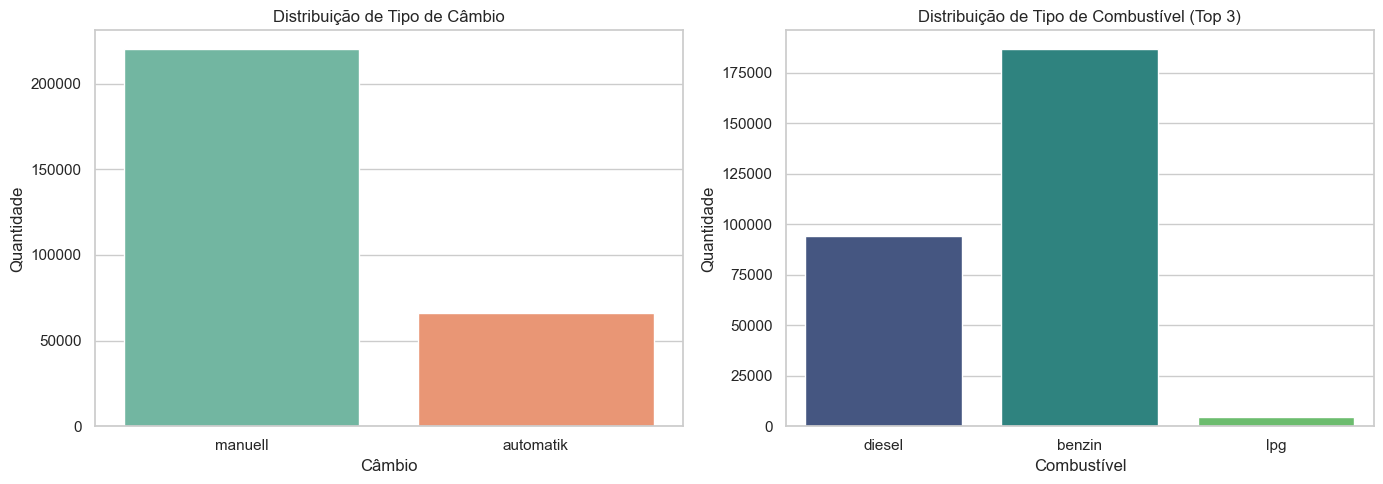

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tipo de Câmbio (Alvo 2 do seu código)
sns.countplot(data=df_eda, x='gearbox', palette='Set2', ax=axes[0])
axes[0].set_title('Distribuição de Tipo de Câmbio')
axes[0].set_xlabel('Câmbio')
axes[0].set_ylabel('Quantidade')

# Gráfico 2: Tipo de Combustível (Alvo 1 do seu código)
# Pegando apenas os 3 mais comuns para limpar o gráfico
top_fuels = df_eda['fuelType'].value_counts().head(3).index
sns.countplot(data=df_eda[df_eda['fuelType'].isin(top_fuels)], x='fuelType', palette='viridis', ax=axes[1])
axes[1].set_title('Distribuição de Tipo de Combustível (Top 3)')
axes[1].set_xlabel('Combustível')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

**Conclusão Parcial:**
Os gráficos mostram que o dataset é desbalanceado. Temos uma prevalência gigantesca de carros manuais (`manuell`) sobre automáticos, e de carros a gasolina (`benzin`) sobre diesel. Isso justifica o cálculo da **Probabilidade A Priori** no nosso modelo de Bayes, pois o algoritmo precisa saber que, "no escuro", chutar que um carro é manual tem muito mais chance de acerto inicial.

C:\Users\Tayro\AppData\Local\Temp\ipykernel_23968\2830181276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['powerPS'] <= 400], x='gearbox', y='powerPS', palette='Set3')


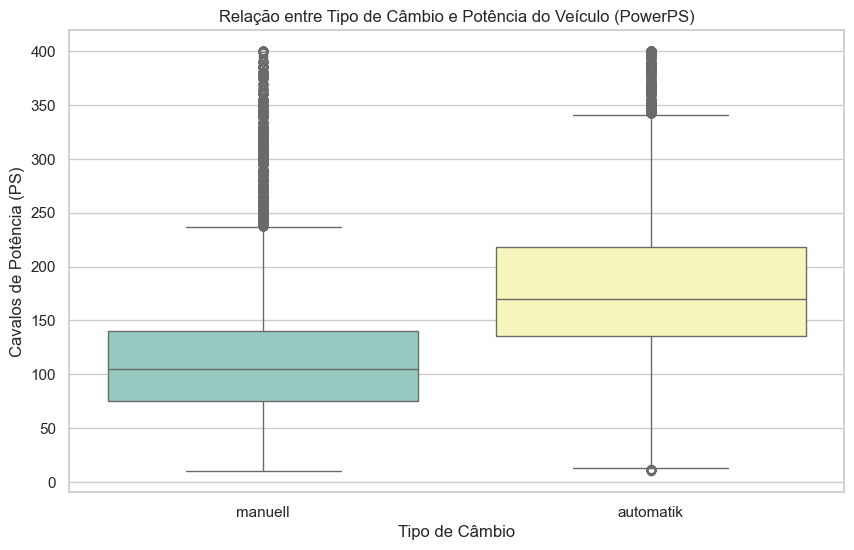

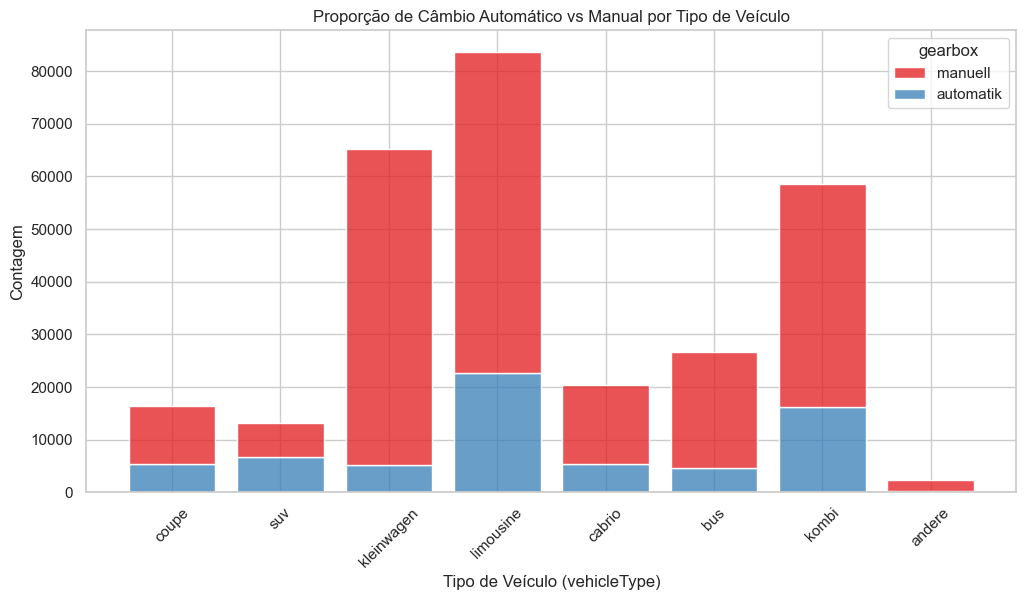

In [4]:
# Relação entre Potência (powerPS) e Câmbio
plt.figure(figsize=(10, 6))
# Filtrando potência até 400 cavalos para melhor visualização
sns.boxplot(data=df_eda[df_eda['powerPS'] <= 400], x='gearbox', y='powerPS', palette='Set3')
plt.title('Relação entre Tipo de Câmbio e Potência do Veículo (PowerPS)')
plt.xlabel('Tipo de Câmbio')
plt.ylabel('Cavalos de Potência (PS)')
plt.show()

# Relação entre Tipo de Veículo e Câmbio
plt.figure(figsize=(12, 6))
sns.histplot(data=df_eda, x='vehicleType', hue='gearbox', multiple='stack', palette='Set1', shrink=0.8)
plt.title('Proporção de Câmbio Automático vs Manual por Tipo de Veículo')
plt.xlabel('Tipo de Veículo (vehicleType)')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

**Análise de Verossimilhança (Likelihood):**
Ao cruzar o câmbio com a potência, notamos claramente que carros automáticos tendem a ter motores mais potentes (a mediana do boxplot é mais alta). Além disso, veículos do tipo SUV ou Limousine possuem uma proporção maior de câmbio automático do que carros pequenos (`kleinwagen`). 
É exatamente **essa variação geométrica** que a função de verossimilhança (Likelihood) do nosso algoritmo de Naive Bayes vai capturar matematicamente a seguir.

---
**Abaixo, inicia-se a implementação manual do Teorema de Bayes e predições probabilísticas:**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Carregar o dataset
df = pd.read_csv("autos_tratado.csv")
df.dtypes

price                  int64
vehicleType            int64
yearOfRegistration     int64
gearbox                int64
powerPS                int64
model                  int64
kilometer              int64
monthOfRegistration    int64
fuelType               int64
brand                  int64
notRepairedDamage      int64
dtype: object

In [70]:
# 1. Definir alvo e preditores
alvo = 'fuelType' # variável alvo, que desejo prever
preditores = ['vehicleType', 'brand']  # variáveis preditoras que são as características usadas como evidência

# 2. Probabilidades a priori
priori = df[alvo].value_counts(normalize=True) # Calcula as probabilidades a priori
print("Probabilidades a priori:")
for classe, prob in priori.items():
    percentual = f"{prob*100:.2f}%".replace('.', ',')
    print(f"P({classe}) = {percentual}")

# 3. Função para calcular verossimilhança
def verossimilhanca(atributo, valor, alvo_classe):
    sub_set = df[df[alvo] == alvo_classe]
    return (sub_set[atributo] == valor).mean()

# 4. Novo dado informado pelo usuário (valores numéricos)
novo_dado = {'vehicleType': 1, 'brand': 5}

# 5. Calcular posterior
posteriores = {}
for classe in df[alvo].unique():
    probabilidade = priori[classe]
    for atributo, valor in novo_dado.items():
        probabilidade *= verossimilhanca(atributo, valor, classe)
    posteriores[classe] = probabilidade

# 6. Normalizar
soma = sum(posteriores.values())
for classe in posteriores:
    posteriores[classe] /= soma

print("Probabilidades a posteriori para o novo dado:")
for classe, probabilidade in posteriores.items():
    percentual = f"{probabilidade*100:.5f}%".replace('.', ',')
    print(f"P({classe}|dados) = {percentual}")


Probabilidades a priori:
P(1.0) = 62,33%
P(3.0) = 31,19%
P(7.0) = 4,67%
P(6.0) = 1,53%
P(2.0) = 0,16%
P(5.0) = 0,08%
P(0.0) = 0,03%
P(4.0) = 0,02%
Probabilidades a posteriori para o novo dado:
P(3.0|dados) = 65,44772%
P(1.0|dados) = 30,70823%
P(7.0|dados) = 1,79959%
P(6.0|dados) = 1,57230%
P(0.0|dados) = 0,00000%
P(5.0|dados) = 0,00000%
P(2.0|dados) = 0,46824%
P(4.0|dados) = 0,00393%


In [62]:
# Criar categorias para powerPS
df['powerPS_cat'] = pd.cut(df['powerPS'], bins=[0,100,200,400,1000], labels=['baixo','medio','alto','muito_alto'])

alvo = 'gearbox'
preditores = ['vehicleType', 'powerPS_cat']
# prever o tipo de câmbio com base no tipo de veículo e na faixa de potência.

# proporção de carros com câmbio manual ou automático no dataset.
priors = df[alvo].value_counts(normalize=True)
print("Probabilidades a priori:")
for classe, prob in priors.items():
    percentual = f"{prob*100:.2f}%".replace('.', ',')
    print(f"P({classe}) = {percentual}")

def verossimilhanca(coluna, valor, classe_alvo): # Filtra o dataset apenas para os carros da classe alvo 
    subset = df[df[alvo] == classe_alvo]          # Calcula a proporção desses carros que têm o valor desejado no atributo
    return (subset[coluna] == valor).mean()

novo_dado = {'vehicleType': 1, 'powerPS_cat': 'medio'} # Esses valores são as evidências usadas para atualizar as probabilidades.

posteriores = {}
for classe in df[alvo].unique():
    probabilidade = priors[classe]
    for coluna, valor in novo_dado.items():
        probabilidade *= verossimilhanca(coluna, valor, classe)
    posteriores[classe] = probabilidade

# Normaliza os valores para que a soma das probabilidades seja igual a 1.
soma = sum(posteriores.values())
for classe in posteriores:
    posteriores[classe] /= soma

print("Probabilidades a posteriori para o novo dado:")
for classe, probabilidade in posteriores.items():
    percentual = f"{probabilidade*100:.2f}%".replace('.', ',')
    print(f"P({classe}|dados) = {percentual}")


Probabilidades a priori:
P(1.0) = 77,43%
P(0.0) = 22,57%
Probabilidades a posteriori para o novo dado:
P(1.0|dados) = 82,67%
P(0.0|dados) = 17,33%


In [61]:
# 1. Criar categorias para preço de forma segura
df.loc[:, 'price_cat'] = pd.cut(
    df['price'],
    bins=[0,2000,10000,50000,100000],
    labels=['baixo','medio','alto','muito_alto']
)

# 2. Remover NaN da coluna alvo
df = df.dropna(subset=['price_cat'])

# 3. Converter para string para evitar problemas de indexação
df.loc[:, 'price_cat'] = df['price_cat'].astype(str)

# 4. Definir alvo e preditoras
alvo = 'price_cat'
preditores = ['yearOfRegistration', 'monthOfRegistration']

# 5. Probabilidades a priori
priors = df[alvo].value_counts(normalize=True)
print("Probabilidades a priori:")
for classe, prob in priors.items():
    percentual = f"{prob*100:.2f}%".replace('.', ',')
    print(f"P({classe}) = {percentual}")

# 6. Função para calcular verossimilhança
def verossimilhanca(coluna, valor, classe_alvo):
    subset = df[df[alvo] == classe_alvo]
    return (subset[coluna] == valor).mean()

# 7. Novo dado informado pelo usuário
novo_dado = {'yearOfRegistration': 2010, 'monthOfRegistration': 6}

# 8. Calcular posterior
posteriores = {}
for classe in df[alvo].unique():
    prob = priors[classe] if classe in priors.index else 0
    for coluna, valor in novo_dado.items():
        prob *= verossimilhanca(coluna, valor, classe)
    posteriores[classe] = prob

# 9. Normalizar
soma = sum(posteriores.values())
if soma > 0:
    for classe in posteriores:
        posteriores[classe] /= soma

# 10. Mostrar resultado
print("Probabilidades a posteriori para o novo dado:")
for classe, prob in posteriores.items():
    print(f"P({classe}|dados) = {prob*100:.2f}%")
    

Probabilidades a priori:
P(medio) = 46,46%
P(baixo) = 34,95%
P(alto) = 18,24%
P(muito_alto) = 0,35%
Probabilidades a posteriori para o novo dado:
P(alto|dados) = 54.75%
P(medio|dados) = 44.42%
P(baixo|dados) = 0.35%
P(muito_alto|dados) = 0.48%
